In [2]:
import torch
import pandas as pd

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = "cuda:0" if torch.cuda.is_available() else "cpu"

print("device:", device)
print("FinRL import 성공")

device: cpu
FinRL import 성공


In [4]:
KOREA_STOCKS = [
    "005930.KS",  # 삼성전자
    "000660.KS",  # SK하이닉스
    "005380.KS",  # 현대차
    "035420.KS",  # NAVER
    "105560.KS",  # KB금융
]

START_DATE = "2018-01-01"
END_DATE = "2026-01-01"

TRAIN_END = pd.Timestamp("2024-01-01")
VAL_END = pd.Timestamp("2025-01-01")

In [5]:
portfolio_raw_df = YahooDownloader(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker_list=KOREA_STOCKS
).fetch_data()

portfolio_raw_df["date"] = pd.to_datetime(
    portfolio_raw_df["date"]
)

print(portfolio_raw_df.head())
print()
print("shape:", portfolio_raw_df.shape)
print("min date:", portfolio_raw_df["date"].min())
print("max date:", portfolio_raw_df["date"].max())

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (9800, 8)
Price       date          close           high            low           open  \
0     2018-01-02   69346.687500   69980.403965   68984.563805   69980.403965   
1     2018-01-02  110675.734375  113266.805079  110305.581417  111416.040291   
2     2018-01-02   41160.609375   41467.176046   40966.988320   41451.040958   
3     2018-01-02  171199.281250  171199.281250  168297.598517  168491.044032   
4     2018-01-02   43072.523438   43618.609313   42594.698296   43618.609313   

Price   volume        tic  day  
0      2014838  000660.KS    1  
1       731763  005380.KS    1  
2      8474250  005930.KS    1  
3       467935  035420.KS    1  
4       576658  105560.KS    1  

shape: (9800, 8)
min date: 2018-01-02 00:00:00
max date: 2025-12-30 00:00:00


In [6]:
stock_count = len(KOREA_STOCKS)

date_counts = (
    portfolio_raw_df
    .groupby("date")["tic"]
    .nunique()
)

common_dates = date_counts[
    date_counts == stock_count
].index

portfolio_raw_df = (
    portfolio_raw_df[
        portfolio_raw_df["date"].isin(common_dates)
    ]
    .sort_values(["date", "tic"])
    .reset_index(drop=True)
)

print(
    portfolio_raw_df
    .groupby("tic")
    .size()
)

tic
000660.KS    1960
005380.KS    1960
005930.KS    1960
035420.KS    1960
105560.KS    1960
dtype: int64


In [7]:
FEATURES = [
    "close",
    "high",
    "low"
]

scaled_data = []
scalers = {}

for tic in KOREA_STOCKS:

    stock_df = (
        portfolio_raw_df[
            portfolio_raw_df["tic"] == tic
        ]
        .copy()
    )

    stock_df[FEATURES] = (
        stock_df[FEATURES]
        .astype(float)
    )

    train_mask = (
        stock_df["date"] < TRAIN_END
    )

    scaler = MaxAbsScaler()

    scaler.fit(
        stock_df.loc[
            train_mask,
            FEATURES
        ]
    )

    stock_df[FEATURES] = scaler.transform(
        stock_df[FEATURES]
    )

    scalers[tic] = scaler
    scaled_data.append(stock_df)

portfolio_norm_df = (
    pd.concat(
        scaled_data,
        ignore_index=True
    )
    .sort_values(["date", "tic"])
    .reset_index(drop=True)
)

portfolio_norm_df.head()

Price,date,close,high,low,open,volume,tic,day
0,2018-01-02,0.492604,0.490500,0.500231,69980.403965,2014838,000660.KS,1
1,2018-01-02,0.515375,0.488202,0.529487,111416.040291,731763,005380.KS,1
2,2018-01-02,0.504408,0.477717,0.510449,41451.040958,8474250,005930.KS,1
3,2018-01-02,0.387474,0.378308,0.382592,168491.044032,467935,035420.KS,1
4,2018-01-02,0.801900,0.804729,0.807735,43618.609313,576658,105560.KS,1


In [8]:
df_portfolio = portfolio_norm_df[
    [
        "date",
        "tic",
        "close",
        "high",
        "low"
    ]
].copy()


df_portfolio_train = df_portfolio[
    df_portfolio["date"] < TRAIN_END
].copy()


df_portfolio_val = df_portfolio[
    (df_portfolio["date"] >= TRAIN_END)
    & (df_portfolio["date"] < VAL_END)
].copy()


df_portfolio_test = df_portfolio[
    df_portfolio["date"] >= VAL_END
].copy()


print("Train:", df_portfolio_train.shape)
print("Validation:", df_portfolio_val.shape)
print("Test:", df_portfolio_test.shape)

print("\nTrain per ticker")
print(df_portfolio_train.groupby("tic").size())

print("\nValidation per ticker")
print(df_portfolio_val.groupby("tic").size())

print("\nTest per ticker")
print(df_portfolio_test.groupby("tic").size())

Train: (7375, 5)
Validation: (1220, 5)
Test: (1205, 5)

Train per ticker
tic
000660.KS    1475
005380.KS    1475
005930.KS    1475
035420.KS    1475
105560.KS    1475
dtype: int64

Validation per ticker
tic
000660.KS    244
005380.KS    244
005930.KS    244
035420.KS    244
105560.KS    244
dtype: int64

Test per ticker
tic
000660.KS    241
005380.KS    241
005930.KS    241
035420.KS    241
105560.KS    241
dtype: int64


In [9]:
#환경 생성
TIME_WINDOW = 50
INITIAL_AMOUNT = 100_000_000

# 일단 원본 예제 값으로 테스트
COMMISSION = 0.0025

environment_train = PortfolioOptimizationEnv(
    df_portfolio_train,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_val = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_test = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

print("환경 생성 완료")


환경 생성 완료


In [10]:
state = environment_train.reset()

print(type(state))
print(state.shape)

<class 'numpy.ndarray'>
(3, 5, 50)


In [17]:
model_kwargs = {
    "lr": 0.01,
    "policy": EIIE,
}

policy_kwargs = {
    "k_size": 3,
    "time_window": TIME_WINDOW,
}

model = DRLAgent(
    environment_train
).get_model(
    "pg",
    device=device,
    model_kwargs=model_kwargs,
    policy_kwargs=policy_kwargs
)

print("EIIE 모델 생성 완료")

EIIE 모델 생성 완료


In [18]:
trained_model = DRLAgent.train_model(
    model,
    episodes=5
)

  0%|          | 0/5 [00:00<?, ?it/s]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\User

Initial portfolio value:100000000
Final portfolio value: 157248672.0
Final accumulative portfolio value: 1.5724867582321167
Maximum DrawDown: -0.3124644719541868
Sharpe ratio: 0.5205481683725046


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 20%|██        | 1/5 [00:45<03:03, 45.95s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 158539888.0
Final accumulative portfolio value: 1.5853989124298096
Maximum DrawDown: -0.31594720015777433
Sharpe ratio: 0.5238330743867256


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 40%|████      | 2/5 [01:09<01:37, 32.49s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

...

C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 60%|██████    | 3/5 [01:32<00:56, 28.20s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 160765584.0
Final accumulative portfolio value: 1.6076558828353882
Maximum DrawDown: -0.32579466439883564
Sharpe ratio: 0.5241164693964007


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 80%|████████  | 4/5 [01:55<00:26, 26.16s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 162099088.0
Final accumulative portfolio value: 1.6209908723831177
Maximum DrawDown: -0.33186620561891
Sharpe ratio: 0.5242093621366085


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 5/5 [02:18<00:00, 27.67s/it]


In [19]:
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "policy_eiie_5ep.pt"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

torch.save(
    model.train_policy.state_dict(),
    MODEL_PATH
)

print("saved:", MODEL_PATH)

saved: C:\code\korea-finrl-portfolio\models\policy_eiie_5ep.pt


In [20]:
policy = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
)

policy.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

print("모델 로드 완료")

모델 로드 완료


In [21]:
DRLAgent.DRL_validation(
    model,
    environment_val,
    policy=policy
)

validation_value = (
    environment_val
    ._asset_memory["final"]
)

print(
    "Validation final value:",
    validation_value[-1]
)

C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\si

Initial portfolio value:100000000
Final portfolio value: 98290000.0
Final accumulative portfolio value: 0.9829000234603882
Maximum DrawDown: -0.19107418356348305
Sharpe ratio: 0.025943273562607977
Validation final value: 98290000.0


In [22]:
environment_val_equal = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

In [23]:
PORTFOLIO_SIZE = len(KOREA_STOCKS)

terminated = False

environment_val_equal.reset()

while not terminated:

    action = (
        [0]
        + [1 / PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    )

    _, _, terminated, _ = environment_val_equal.step(
        action
    )

equal_value = environment_val_equal._asset_memory["final"]

print(
    "Equal-weight final value:",
    equal_value[-1]
)

Initial portfolio value:100000000
Final portfolio value: 98210016.0
Final accumulative portfolio value: 0.9821001887321472
Maximum DrawDown: -0.20156506074614666
Sharpe ratio: 0.03520589876103309
Equal-weight final value: 98210020.0


In [24]:
eiie_final = validation_value[-1]
equal_final = equal_value[-1]

comparison = pd.DataFrame({
    "Strategy": [
        "EIIE",
        "Equal Weight"
    ],
    "Final Value": [
        eiie_final,
        equal_final
    ],
    "Return (%)": [
        (eiie_final / INITIAL_AMOUNT - 1) * 100,
        (equal_final / INITIAL_AMOUNT - 1) * 100
    ]
})

comparison

,Strategy,Final Value,Return (%)
0,EIIE,98290000.0,-1.709998
1,Equal Weight,98210016.0,-1.789981


In [25]:
# EIIE가 2024 Validation에서 선택한 포트폴리오 비중 확인

action_columns = (
    ["Cash"]
    + list(environment_val._tic_list)
)

actions_df = pd.DataFrame(
    environment_val._actions_memory,
    columns=action_columns
)

actions_df.index = pd.to_datetime(
    environment_val._date_memory
)

actions_df.head()

,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2024-03-14,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-15,0.089099,0.182180,0.182180,0.182180,0.182180,0.182180
2024-03-18,0.083838,0.183232,0.183232,0.183232,0.183232,0.183232
2024-03-19,0.083808,0.183238,0.183238,0.183238,0.183238,0.183238
2024-03-20,0.083808,0.183238,0.183238,0.183238,0.183238,0.183238


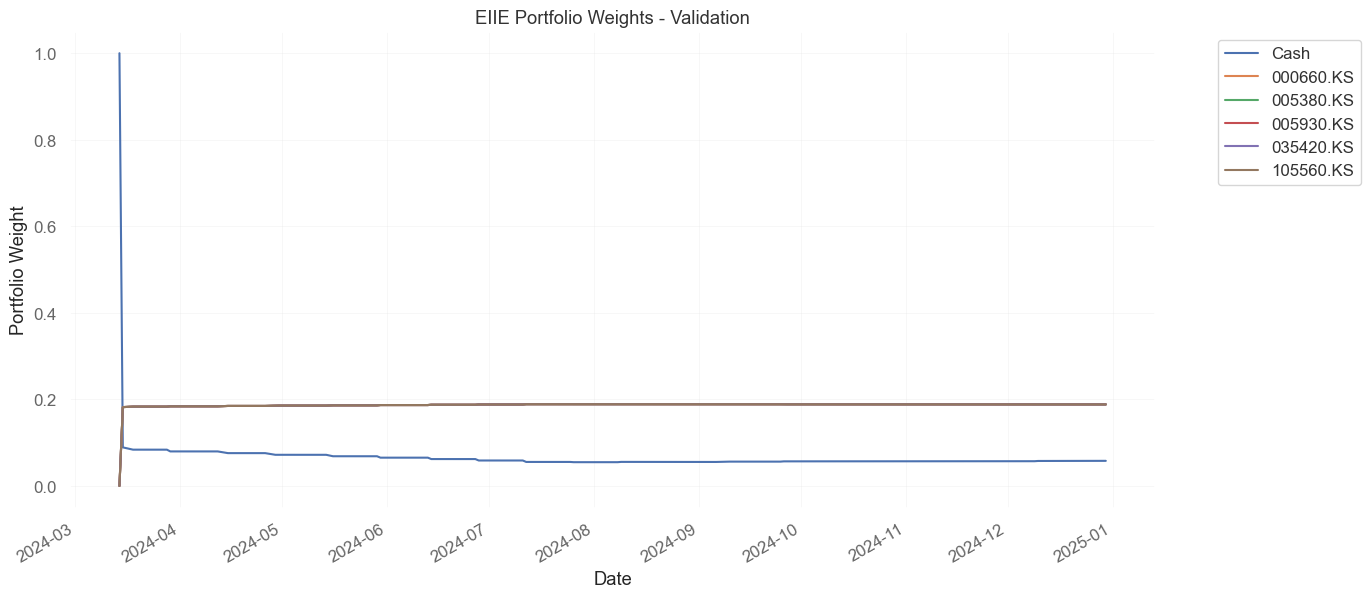

In [26]:
import matplotlib.pyplot as plt

actions_df.plot(
    figsize=(14, 7)
)

plt.title("EIIE Portfolio Weights - Validation")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.show()

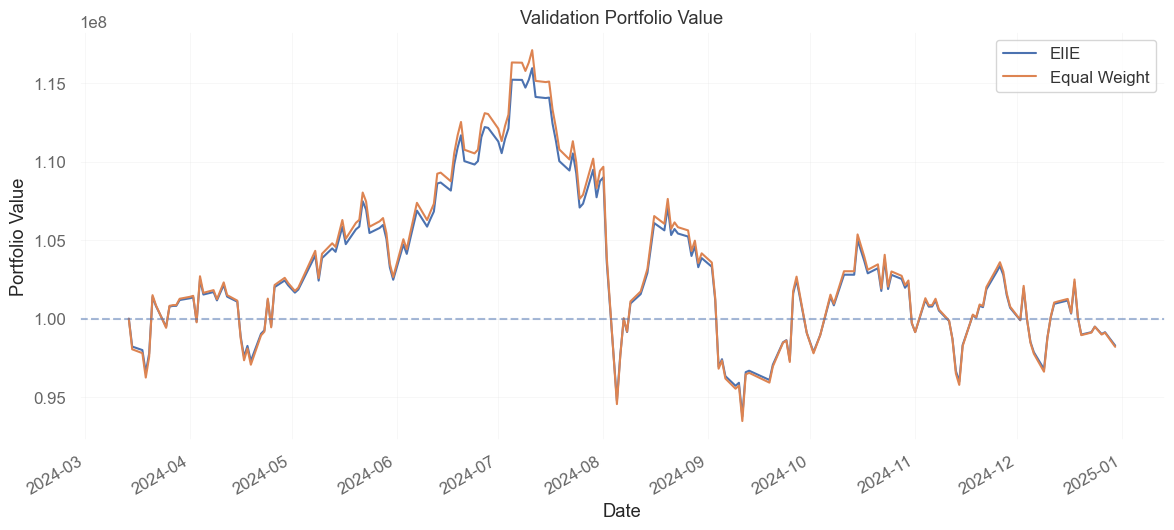

In [27]:
eiie_curve = pd.Series(
    environment_val._asset_memory["final"],
    index=pd.to_datetime(environment_val._date_memory),
    name="EIIE"
)

equal_curve = pd.Series(
    environment_val_equal._asset_memory["final"],
    index=pd.to_datetime(environment_val_equal._date_memory),
    name="Equal Weight"
)

comparison_curve = pd.concat(
    [eiie_curve, equal_curve],
    axis=1
)

comparison_curve.plot(
    figsize=(14, 6)
)

plt.axhline(
    INITIAL_AMOUNT,
    linestyle="--",
    alpha=0.5
)

plt.title("Validation Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.show()

In [28]:
environment_val_fixed = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

policy_fixed = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
)

policy_fixed.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

DRLAgent.DRL_validation(
    model,
    environment_val_fixed,
    policy=policy_fixed,
    online_training_period=10**9,
    learning_rate=0
)

print(
    "Fixed-policy Validation final value:",
    environment_val_fixed._asset_memory["final"][-1]
)

Initial portfolio value:100000000
Final portfolio value: 98561952.0
Final accumulative portfolio value: 0.9856195449829102
Maximum DrawDown: -0.18563933920789588
Sharpe ratio: 0.035907394264422625
Fixed-policy Validation final value: 98561950.0


In [29]:
action_columns = [
    "Cash",
    *environment_val_fixed._tic_list
]

actions_fixed = pd.DataFrame(
    environment_val_fixed._actions_memory,
    columns=action_columns
)

actions_fixed.index = pd.to_datetime(
    environment_val_fixed._date_memory
)

stock_columns = list(
    environment_val_fixed._tic_list
)

stock_spread = (
    actions_fixed[stock_columns].max(axis=1)
    - actions_fixed[stock_columns].min(axis=1)
)

print(
    "주식 비중 최대 차이:",
    stock_spread.iloc[1:].max()
)

print(
    "평균 Cash 비중:",
    actions_fixed["Cash"].iloc[1:].mean()
)

actions_fixed.head()

주식 비중 최대 차이: 0.0
평균 Cash 비중: 0.083835505


,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2024-03-14,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-15,0.089099,0.182180,0.182180,0.182180,0.182180,0.182180
2024-03-18,0.083838,0.183232,0.183232,0.183232,0.183232,0.183232
2024-03-19,0.083808,0.183238,0.183238,0.183238,0.183238,0.183238
2024-03-20,0.083808,0.183238,0.183238,0.183238,0.183238,0.183238


In [30]:
cash_series = actions_fixed["Cash"].iloc[1:]

print("Cash 평균:", cash_series.mean())
print("Cash 최소:", cash_series.min())
print("Cash 최대:", cash_series.max())
print("Cash 표준편차:", cash_series.std())

Cash 평균: 0.083835505
Cash 최소: 0.08380809426307678
Cash 최대: 0.08909868448972702
Cash 표준편차: 0.0003798370307777077


In [31]:
STATIC_CASH = cash_series.mean()
STATIC_STOCK = (1 - STATIC_CASH) / len(KOREA_STOCKS)

print("고정 현금 비중:", STATIC_CASH)
print("종목당 비중:", STATIC_STOCK)

고정 현금 비중: 0.083835505
종목당 비중: 0.1832329


In [32]:
environment_val_static_cash = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_val_static_cash.reset()

done = False

while not done:

    action = (
        [STATIC_CASH]
        + [STATIC_STOCK] * len(KOREA_STOCKS)
    )

    _, _, done, _ = environment_val_static_cash.step(
        action
    )

Initial portfolio value:100000000
Final portfolio value: 98550576.0
Final accumulative portfolio value: 0.9855057597160339
Maximum DrawDown: -0.1856345395732959
Sharpe ratio: 0.03526929575006448


In [33]:
static_cash_final = (
    environment_val_static_cash
    ._asset_memory["final"][-1]
)

comparison = pd.DataFrame({
    "Strategy": [
        "EIIE",
        "Equal Weight",
        "Equal Weight + Fixed Cash"
    ],
    "Final Value": [
        environment_val_fixed._asset_memory["final"][-1],
        equal_final,
        static_cash_final
    ]
})

comparison["Return (%)"] = (
    comparison["Final Value"]
    / INITIAL_AMOUNT
    - 1
) * 100

comparison

,Strategy,Final Value,Return (%)
0,EIIE,98561952.0,-1.438046
1,Equal Weight,98210016.0,-1.789981
2,Equal Weight + Fixed Cash,98550576.0,-1.449424


In [34]:
import numpy as np

obs = environment_val_fixed.reset()

print("Observation shape:", obs.shape)

Observation shape: (3, 5, 50)


In [35]:
for i, tic in enumerate(environment_val_fixed._tic_list):
    stock_obs = obs[:, i, :]

    print(
        tic,
        "mean =", stock_obs.mean(),
        "std =", stock_obs.std(),
        "min =", stock_obs.min(),
        "max =", stock_obs.max()
    )

000660.KS mean = 1.0232215 std = 0.08417483 min = 0.91467226 max = 1.2066944
005380.KS mean = 0.8832501 std = 0.1278258 min = 0.68524534 max = 1.0971702
005930.KS mean = 0.85403514 std = 0.028349353 min = 0.7922664 max = 0.9317209
035420.KS mean = 0.46320665 std = 0.029261634 min = 0.4121547 max = 0.51597464
105560.KS mean = 1.0140038 std = 0.14511174 min = 0.8178363 max = 1.3380002


In [36]:
for i in range(len(KOREA_STOCKS) - 1):
    diff = np.abs(
        obs[:, i, :]
        - obs[:, i + 1, :]
    ).mean()

    print(
        environment_val_fixed._tic_list[i],
        "vs",
        environment_val_fixed._tic_list[i + 1],
        "평균 절대 차이:",
        diff
    )

000660.KS vs 005380.KS 평균 절대 차이: 0.14238033
005380.KS vs 005930.KS 평균 절대 차이: 0.12743919
005930.KS vs 035420.KS 평균 절대 차이: 0.39082846
035420.KS vs 105560.KS 평균 절대 차이: 0.55079705


In [37]:
obs_tensor = torch.tensor(
    obs,
    dtype=torch.float32,
    device=device
).unsqueeze(0)

with torch.no_grad():
    cnn_output = policy_fixed.sequential(
        obs_tensor
    )

print("CNN output shape:", cnn_output.shape)

print(
    "CNN output 평균:",
    cnn_output.mean().item()
)

print(
    "CNN output 최대:",
    cnn_output.max().item()
)

print(
    "CNN output 0 비율:",
    (cnn_output == 0).float().mean().item()
)

CNN output shape: torch.Size([1, 20, 5, 1])
CNN output 평균: 0.0940733551979065
CNN output 최대: 0.28391140699386597
CNN output 0 비율: 0.550000011920929


In [38]:
with torch.no_grad():

    stock_feature_mean = (
        cnn_output
        .mean(dim=1)
        .squeeze()
        .cpu()
        .numpy()
    )

for tic, value in zip(
    environment_val_fixed._tic_list,
    stock_feature_mean
):
    print(tic, value)

000660.KS 0.094073355
005380.KS 0.094073355
005930.KS 0.094073355
035420.KS 0.094073355
105560.KS 0.09407335


In [39]:
# shape: [1, 20, 5, 1]
features = cnn_output.squeeze(0).squeeze(-1)

print("features shape:", features.shape)

for i in range(len(environment_val_fixed._tic_list) - 1):

    diff = torch.abs(
        features[:, i] - features[:, i + 1]
    )

    print(
        environment_val_fixed._tic_list[i],
        "vs",
        environment_val_fixed._tic_list[i + 1],
        "mean diff =", diff.mean().item(),
        "max diff =", diff.max().item()
    )

features shape: torch.Size([20, 5])
000660.KS vs 005380.KS mean diff = 0.0 max diff = 0.0
005380.KS vs 005930.KS mean diff = 0.0 max diff = 0.0
005930.KS vs 035420.KS mean diff = 0.0 max diff = 0.0
035420.KS vs 105560.KS mean diff = 0.0 max diff = 0.0


In [40]:
print(
    "000660.KS\n",
    features[:, 0].cpu().numpy()
)

print(
    "\n005380.KS\n",
    features[:, 1].cpu().numpy()
)

000660.KS
 [0.         0.         0.         0.22468416 0.2839114  0.
 0.21451886 0.19019738 0.21859778 0.         0.         0.23947452
 0.25806868 0.24415396 0.         0.         0.         0.
 0.         0.00786025]

005380.KS
 [0.         0.         0.         0.22468416 0.2839114  0.
 0.21451886 0.19019738 0.21859778 0.         0.         0.23947452
 0.25806868 0.24415396 0.         0.         0.         0.
 0.         0.00786025]


In [41]:
last_action = torch.tensor(
    [[1.0, 0, 0, 0, 0, 0]],
    dtype=torch.float32,
    device=device
)

In [42]:
with torch.no_grad():

    last_stocks, cash_bias = (
        policy_fixed._process_last_action(
            last_action
        )
    )

    # FinRL EIIE는 cash logit을 0으로 둠
    cash_bias = torch.zeros_like(
        cash_bias
    )

    cnn_features = policy_fixed.sequential(
        obs_tensor
    )

    combined = torch.cat(
        [last_stocks, cnn_features],
        dim=1
    )

    stock_logits = (
        policy_fixed
        .final_convolution(combined)
    )

    print(
        "stock logits:",
        stock_logits
        .squeeze()
        .cpu()
        .numpy()
    )

stock logits: [0.71525204 0.71525204 0.71525204 0.71525204 0.71525204]


In [43]:
print(
    "final convolution weights:\n",
    policy_fixed
    .final_convolution
    .weight
    .detach()
    .cpu()
    .numpy()
)

print(
    "\nfinal convolution bias:\n",
    policy_fixed
    .final_convolution
    .bias
    .detach()
    .cpu()
    .numpy()
)

final convolution weights:
 [[[[ 0.36567846]]

  [[-0.08670995]]

  [[ 0.01050708]]

  [[ 0.04979474]]

  [[ 0.22394644]]

  [[ 0.2703981 ]]

  [[-0.07828072]]

  [[ 0.15948254]]

  [[ 0.15540592]]

  [[ 0.38965508]]

  [[-0.12854756]]

  [[ 0.03313996]]

  [[ 0.3214021 ]]

  [[ 0.36884376]]

  [[ 0.34512916]]

  [[ 0.00857533]]

  [[ 0.1008669 ]]

  [[ 0.00138716]]

  [[-0.09597991]]

  [[ 0.10190888]]

  [[ 0.00359661]]]]

final convolution bias:
 [0.1827707]


In [44]:
fresh_policy = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
).to(device)

with torch.no_grad():

    fresh_cnn = fresh_policy.sequential(
        obs_tensor
    )

fresh_features = (
    fresh_cnn
    .squeeze(0)
    .squeeze(-1)
)

print("=== 학습 전 새 EIIE ===")

for i in range(
    len(environment_val_fixed._tic_list) - 1
):

    diff = torch.abs(
        fresh_features[:, i]
        - fresh_features[:, i + 1]
    )

    print(
        environment_val_fixed._tic_list[i],
        "vs",
        environment_val_fixed._tic_list[i + 1],
        "mean diff =",
        diff.mean().item(),
        "max diff =",
        diff.max().item()
    )

=== 학습 전 새 EIIE ===
000660.KS vs 005380.KS mean diff = 0.009754469618201256 max diff = 0.025295406579971313
005380.KS vs 005930.KS mean diff = 0.004362467676401138 max diff = 0.014411628246307373
005930.KS vs 035420.KS mean diff = 0.026901453733444214 max diff = 0.07638109475374222
035420.KS vs 105560.KS mean diff = 0.033926595002412796 max diff = 0.10351965576410294


In [45]:
with torch.no_grad():

    fresh_action = fresh_policy.mu(
        obs_tensor,
        last_action
    )

print(
    "학습 전 action:",
    fresh_action
        .squeeze()
        .cpu()
        .numpy()
)

학습 전 action: [0.13991691 0.17180061 0.1715865  0.17219083 0.17309628 0.17140885]


In [46]:
with torch.no_grad():

    # 첫 번째 Conv
    conv1 = policy_fixed.sequential[0](
        obs_tensor
    )

    relu1 = policy_fixed.sequential[1](
        conv1
    )

    # 두 번째 Conv
    conv2 = policy_fixed.sequential[2](
        relu1
    )

    relu2 = policy_fixed.sequential[3](
        conv2
    )


def compare_stocks(name, tensor):

    print(f"\n=== {name} ===")

    for i in range(
        len(environment_val_fixed._tic_list) - 1
    ):

        diff = torch.abs(
            tensor[:, :, i, :]
            - tensor[:, :, i + 1, :]
        )

        print(
            environment_val_fixed._tic_list[i],
            "vs",
            environment_val_fixed._tic_list[i + 1],
            "mean diff =",
            diff.mean().item(),
            "max diff =",
            diff.max().item()
        )


compare_stocks("Conv1", conv1)
compare_stocks("ReLU1", relu1)
compare_stocks("Conv2", conv2)
compare_stocks("ReLU2", relu2)


=== Conv1 ===
000660.KS vs 005380.KS mean diff = 0.05498698353767395 max diff = 0.16389533877372742
005380.KS vs 005930.KS mean diff = 0.05015777051448822 max diff = 0.11755788326263428
005930.KS vs 035420.KS mean diff = 0.15675245225429535 max diff = 0.2446674108505249
035420.KS vs 105560.KS mean diff = 0.21012775599956512 max diff = 0.4909462630748749

=== ReLU1 ===
000660.KS vs 005380.KS mean diff = 0.0 max diff = 0.0
005380.KS vs 005930.KS mean diff = 0.0 max diff = 0.0
005930.KS vs 035420.KS mean diff = 0.0 max diff = 0.0
035420.KS vs 105560.KS mean diff = 0.0 max diff = 0.0

=== Conv2 ===
000660.KS vs 005380.KS mean diff = 0.0 max diff = 0.0
005380.KS vs 005930.KS mean diff = 0.0 max diff = 0.0
005930.KS vs 035420.KS mean diff = 0.0 max diff = 0.0
035420.KS vs 105560.KS mean diff = 0.0 max diff = 0.0

=== ReLU2 ===
000660.KS vs 005380.KS mean diff = 0.0 max diff = 0.0
005380.KS vs 005930.KS mean diff = 0.0 max diff = 0.0
005930.KS vs 035420.KS mean diff = 0.0 max diff = 0.0
0354

In [47]:
print("Conv1 min:", conv1.min().item())
print("Conv1 max:", conv1.max().item())

print("ReLU1 min:", relu1.min().item())
print("ReLU1 max:", relu1.max().item())

print(
    "ReLU1 zero ratio:",
    (relu1 == 0).float().mean().item()
)

Conv1 min: -0.7675789594650269
Conv1 max: -0.2760107219219208
ReLU1 min: 0.0
ReLU1 max: 0.0
ReLU1 zero ratio: 1.0


In [48]:
environment_train_lr001 = PortfolioOptimizationEnv(
    df_portfolio_train,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

In [49]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [50]:
model_kwargs_lr001 = {
    "lr": 0.001,
    "policy": EIIE,
}

policy_kwargs_lr001 = {
    "k_size": 3,
    "time_window": TIME_WINDOW,
}

model_lr001 = DRLAgent(
    environment_train_lr001
).get_model(
    "pg",
    device=device,
    model_kwargs=model_kwargs_lr001,
    policy_kwargs=policy_kwargs_lr001
)

print("lr=0.001 모델 생성 완료")

lr=0.001 모델 생성 완료


In [51]:
DRLAgent.train_model(
    model_lr001,
    episodes=5
)


  0%|          | 0/5 [00:00<?, ?it/s]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\User

Initial portfolio value:100000000
Final portfolio value: 158631744.0
Final accumulative portfolio value: 1.5863174200057983
Maximum DrawDown: -0.3036998884088413
Sharpe ratio: 0.5452140604810831


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 20%|██        | 1/5 [00:26<01:45, 26.31s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 161152912.0
Final accumulative portfolio value: 1.6115291118621826
Maximum DrawDown: -0.30008420333590113
Sharpe ratio: 0.5636646514658864


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 40%|████      | 2/5 [00:51<01:17, 25.90s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

...

C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 60%|██████    | 3/5 [01:17<00:51, 25.95s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 161869936.0
Final accumulative portfolio value: 1.618699312210083
Maximum DrawDown: -0.3036714823849077
Sharpe ratio: 0.5633241716089136


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 80%|████████  | 4/5 [01:43<00:25, 25.81s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 162496304.0
Final accumulative portfolio value: 1.6249630451202393
Maximum DrawDown: -0.30401782992213733
Sharpe ratio: 0.566802804732093


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 5/5 [02:09<00:00, 25.97s/it]


In [52]:
policy_lr001 = model_lr001.train_policy

with torch.no_grad():

    cnn_lr001 = policy_lr001.sequential(
        obs_tensor
    )

features_lr001 = (
    cnn_lr001
    .squeeze(0)
    .squeeze(-1)
)

for i in range(
    len(environment_val_fixed._tic_list) - 1
):

    diff = torch.abs(
        features_lr001[:, i]
        - features_lr001[:, i + 1]
    )

    print(
        environment_val_fixed._tic_list[i],
        "vs",
        environment_val_fixed._tic_list[i + 1],
        "mean diff =",
        diff.mean().item(),
        "max diff =",
        diff.max().item()
    )

000660.KS vs 005380.KS mean diff = 0.04648832231760025 max diff = 0.2607346773147583
005380.KS vs 005930.KS mean diff = 0.026587646454572678 max diff = 0.09045249223709106
005930.KS vs 035420.KS mean diff = 0.1096673458814621 max diff = 0.48499059677124023
035420.KS vs 105560.KS mean diff = 0.15591661632061005 max diff = 0.6310505867004395


In [53]:
with torch.no_grad():

    conv1_lr001 = policy_lr001.sequential[0](
        obs_tensor
    )

    relu1_lr001 = policy_lr001.sequential[1](
        conv1_lr001
    )

print(
    "ReLU1 zero ratio:",
    (relu1_lr001 == 0)
    .float()
    .mean()
    .item()
)

print(
    "ReLU1 max:",
    relu1_lr001.max().item()
)

ReLU1 zero ratio: 0.0
ReLU1 max: 1.2340128421783447


In [54]:
MODEL_PATH_LR001 = (
    PROJECT_ROOT
    / "models"
    / "policy_eiie_lr001_5ep.pt"
)

torch.save(
    model_lr001.train_policy.state_dict(),
    MODEL_PATH_LR001
)

print("saved:", MODEL_PATH_LR001)

saved: C:\code\korea-finrl-portfolio\models\policy_eiie_lr001_5ep.pt


In [56]:
environment_val_lr001 = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

policy_lr001_fixed = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
)

policy_lr001_fixed.load_state_dict(
    torch.load(
        MODEL_PATH_LR001,
        map_location=device
    )
)

DRLAgent.DRL_validation(
    model_lr001,
    environment_val_lr001,
    policy=policy_lr001_fixed,
    online_training_period=10**9,
    learning_rate=0
)

lr001_final = (
    environment_val_lr001
    ._asset_memory["final"][-1]
)

print(
    "lr=0.001 Fixed Validation final value:",
    lr001_final
)

Initial portfolio value:100000000
Final portfolio value: 99526320.0
Final accumulative portfolio value: 0.9952632188796997
Maximum DrawDown: -0.14387082695724374
Sharpe ratio: 0.05742911142072672
lr=0.001 Fixed Validation final value: 99526320.0


In [57]:
action_columns = [
    "Cash",
    *environment_val_lr001._tic_list
]

actions_lr001 = pd.DataFrame(
    environment_val_lr001._actions_memory,
    columns=action_columns
)

actions_lr001.index = pd.to_datetime(
    environment_val_lr001._date_memory
)

stock_columns = list(
    environment_val_lr001._tic_list
)

stock_spread_lr001 = (
    actions_lr001[stock_columns].max(axis=1)
    - actions_lr001[stock_columns].min(axis=1)
)

print(
    "주식 비중 최대 차이:",
    stock_spread_lr001.iloc[1:].max()
)

print(
    "주식 비중 평균 차이:",
    stock_spread_lr001.iloc[1:].mean()
)

print(
    "평균 Cash 비중:",
    actions_lr001["Cash"].iloc[1:].mean()
)

print(
    "Cash 최소:",
    actions_lr001["Cash"].iloc[1:].min()
)

print(
    "Cash 최대:",
    actions_lr001["Cash"].iloc[1:].max()
)

actions_lr001.head()

주식 비중 최대 차이: 0.1325724720954895
주식 비중 평균 차이: 0.11514641
평균 Cash 비중: 0.23851368
Cash 최소: 0.2250286042690277
Cash 최대: 0.2492128163576126


,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2024-03-14,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-15,0.225997,0.133210,0.148817,0.153579,0.201078,0.137320
2024-03-18,0.225029,0.133468,0.147934,0.154308,0.202718,0.136543
2024-03-19,0.225541,0.133646,0.147566,0.154617,0.203916,0.134714
2024-03-20,0.226215,0.133084,0.147612,0.154552,0.205387,0.133150


In [58]:
comparison_lr = pd.DataFrame({
    "Strategy": [
        "EIIE lr=0.01",
        "EIIE lr=0.001",
        "Equal Weight"
    ],
    "Final Value": [
        environment_val_fixed._asset_memory["final"][-1],
        lr001_final,
        equal_final
    ]
})

comparison_lr["Return (%)"] = (
    comparison_lr["Final Value"]
    / INITIAL_AMOUNT
    - 1
) * 100

comparison_lr

,Strategy,Final Value,Return (%)
0,EIIE lr=0.01,100000000.0,0.000000
1,EIIE lr=0.001,99526320.0,-0.473680
2,Equal Weight,98210016.0,-1.789984


In [59]:
STATIC_CASH_LR001 = (
    actions_lr001["Cash"]
    .iloc[1:]
    .mean()
)

STATIC_STOCK_LR001 = (
    1 - STATIC_CASH_LR001
) / len(KOREA_STOCKS)

print("Fixed Cash:", STATIC_CASH_LR001)
print("Each Stock:", STATIC_STOCK_LR001)

Fixed Cash: 0.23851368
Each Stock: 0.15229726


In [60]:
environment_val_static_lr001 = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_val_static_lr001.reset()

done = False

while not done:

    action = (
        [STATIC_CASH_LR001]
        + [STATIC_STOCK_LR001] * len(KOREA_STOCKS)
    )

    _, _, done, _ = environment_val_static_lr001.step(
        action
    )

Initial portfolio value:100000000
Final portfolio value: 99079528.0
Final accumulative portfolio value: 0.9907952547073364
Maximum DrawDown: -0.15580345181250665
Sharpe ratio: 0.03477780961908495


In [61]:
static_lr001_final = (
    environment_val_static_lr001
    ._asset_memory["final"][-1]
)

print(
    "Fixed Cash + Equal Weight:",
    static_lr001_final
)

print(
    "Return:",
    (
        static_lr001_final
        / INITIAL_AMOUNT
        - 1
    ) * 100
)

Fixed Cash + Equal Weight: 99079530.0
Return: -0.9204745


In [62]:
# 기존 lr=0.001 모델에 5 episode 추가
# 현재 5회 학습된 상태이므로 실행 후 총 10 episodes

DRLAgent.train_model(
    model_lr001,
    episodes=5
)

print("총 10 episodes 학습 완료")

  0%|          | 0/5 [00:00<?, ?it/s]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\User

Initial portfolio value:100000000
Final portfolio value: 163214336.0
Final accumulative portfolio value: 1.6321433782577515
Maximum DrawDown: -0.3042096675089767
Sharpe ratio: 0.5710294439305181


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 20%|██        | 1/5 [00:27<01:48, 27.12s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 163997280.0
Final accumulative portfolio value: 1.6399728059768677
Maximum DrawDown: -0.30438798219202223
Sharpe ratio: 0.5756693322532137


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 40%|████      | 2/5 [00:54<01:21, 27.03s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

...

Initial portfolio value:100000000
Final portfolio value: 165796352.0
Final accumulative portfolio value: 1.657963514328003
Maximum DrawDown: -0.3047357973496059
Sharpe ratio: 0.586242097289603


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 80%|████████  | 4/5 [01:45<00:26, 26.25s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Initial portfolio value:100000000
Final portfolio value: 166788784.0
Final accumulative portfolio value: 1.667887806892395
Maximum DrawDown: -0.30524363217233574
Sharpe ratio: 0.5913188009848726


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 5/5 [02:12<00:00, 26.45s/it]

총 10 episodes 학습 완료


In [63]:
MODEL_PATH_LR001_10EP = (
    PROJECT_ROOT
    / "models"
    / "policy_eiie_lr001_10ep.pt"
)

torch.save(
    model_lr001.train_policy.state_dict(),
    MODEL_PATH_LR001_10EP
)

print("saved:", MODEL_PATH_LR001_10EP)

saved: C:\code\korea-finrl-portfolio\models\policy_eiie_lr001_10ep.pt


In [64]:
environment_val_10ep = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

policy_10ep = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
)

policy_10ep.load_state_dict(
    torch.load(
        MODEL_PATH_LR001_10EP,
        map_location=device
    )
)

DRLAgent.DRL_validation(
    model_lr001,
    environment_val_10ep,
    policy=policy_10ep,
    online_training_period=10**9,
    learning_rate=0
)

Initial portfolio value:100000000
Final portfolio value: 99843488.0
Final accumulative portfolio value: 0.9984349012374878
Maximum DrawDown: -0.13463507316596923
Sharpe ratio: 0.07544404803171391


In [65]:
final_10ep = (
    environment_val_10ep
    ._asset_memory["final"][-1]
)

comparison_episode = pd.DataFrame({
    "Episodes": [5, 10],
    "Final Value": [
        99_526_320,
        final_10ep
    ]
})

comparison_episode["Return (%)"] = (
    comparison_episode["Final Value"]
    / INITIAL_AMOUNT
    - 1
) * 100

comparison_episode

,Episodes,Final Value,Return (%)
0,5,99526320.0,-0.473680
1,10,99843488.0,-0.156512


In [66]:
action_columns = [
    "Cash",
    *environment_val_10ep._tic_list
]

actions_10ep = pd.DataFrame(
    environment_val_10ep._actions_memory,
    columns=action_columns
)

actions_10ep.index = pd.to_datetime(
    environment_val_10ep._date_memory
)

stock_columns = list(
    environment_val_10ep._tic_list
)

stock_spread_10ep = (
    actions_10ep[stock_columns].max(axis=1)
    - actions_10ep[stock_columns].min(axis=1)
)

print(
    "주식 비중 최대 차이:",
    stock_spread_10ep.iloc[1:].max()
)

print(
    "주식 비중 평균 차이:",
    stock_spread_10ep.iloc[1:].mean()
)

print(
    "평균 Cash 비중:",
    actions_10ep["Cash"].iloc[1:].mean()
)

print(
    "Cash 최소:",
    actions_10ep["Cash"].iloc[1:].min()
)

print(
    "Cash 최대:",
    actions_10ep["Cash"].iloc[1:].max()
)

actions_10ep.head()

주식 비중 최대 차이: 0.19787806272506714
주식 비중 평균 차이: 0.1716146
평균 Cash 비중: 0.25573075
Cash 최소: 0.23895271122455597
Cash 최대: 0.27024519443511963


,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2024-03-14,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-15,0.240726,0.121144,0.140634,0.148569,0.224655,0.124273
2024-03-18,0.238953,0.121169,0.139504,0.149469,0.227825,0.123080
2024-03-19,0.239483,0.121077,0.138975,0.149777,0.229436,0.121252
2024-03-20,0.240167,0.120262,0.138890,0.149688,0.231296,0.119698


In [67]:
STATIC_CASH_10EP = (
    actions_10ep["Cash"]
    .iloc[1:]
    .mean()
)

STATIC_STOCK_10EP = (
    1 - STATIC_CASH_10EP
) / len(KOREA_STOCKS)

print("Fixed Cash:", STATIC_CASH_10EP)
print("Each Stock:", STATIC_STOCK_10EP)

Fixed Cash: 0.25573075
Each Stock: 0.14885385


In [68]:
environment_val_static_10ep = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_val_static_10ep.reset()

done = False

while not done:

    action = (
        [STATIC_CASH_10EP]
        + [STATIC_STOCK_10EP] * len(KOREA_STOCKS)
    )

    _, _, done, _ = environment_val_static_10ep.step(
        action
    )

Initial portfolio value:100000000
Final portfolio value: 99131808.0
Final accumulative portfolio value: 0.9913181066513062
Maximum DrawDown: -0.15244386470914584
Sharpe ratio: 0.0347522323359412


In [69]:
static_10ep_final = (
    environment_val_static_10ep
    ._asset_memory["final"][-1]
)

static_10ep_return = (
    static_10ep_final
    / INITIAL_AMOUNT
    - 1
) * 100

print(
    "Fixed Cash + Equal Weight:",
    static_10ep_final
)

print(
    "Return:",
    static_10ep_return
)


Fixed Cash + Equal Weight: 99131810.0
Return: -0.86818933


In [70]:
comparison_10ep = pd.DataFrame({
    "Strategy": [
        "EIIE 10ep",
        "25.57% Cash + Equal Weight",
        "Equal Weight"
    ],
    "Final Value": [
        final_10ep,
        static_10ep_final,
        equal_final
    ]
})

comparison_10ep["Return (%)"] = (
    comparison_10ep["Final Value"]
    / INITIAL_AMOUNT
    - 1
) * 100

comparison_10ep

,Strategy,Final Value,Return (%)
0,EIIE 10ep,99843488.0,-0.156510
1,25.57% Cash + Equal Weight,99131808.0,-0.868189
2,Equal Weight,98210016.0,-1.789981


In [71]:
DRLAgent.train_model(
    model_lr001,
    episodes=10
)

print("총 20 episodes 학습 완료")

  0%|          | 0/10 [00:00<?, ?it/s]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Use

Initial portfolio value:100000000
Final portfolio value: 167852032.0
Final accumulative portfolio value: 1.6785203218460083
Maximum DrawDown: -0.3058508287971833
Sharpe ratio: 0.5968248563845506


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 10%|█         | 1/10 [00:28<04:17, 28.58s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader

Initial portfolio value:100000000
Final portfolio value: 169113280.0
Final accumulative portfolio value: 1.6911327838897705
Maximum DrawDown: -0.30626922557716063
Sharpe ratio: 0.6037487806401057


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 20%|██        | 2/10 [00:55<03:38, 27.35s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader

...

Initial portfolio value:100000000
Final portfolio value: 183163840.0
Final accumulative portfolio value: 1.8316384553909302
Maximum DrawDown: -0.31555500052082297
Sharpe ratio: 0.6638570661948284


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 90%|█████████ | 9/10 [04:07<00:27, 27.99s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader

Initial portfolio value:100000000
Final portfolio value: 186263856.0
Final accumulative portfolio value: 1.8626385927200317
Maximum DrawDown: -0.31810864525363547
Sharpe ratio: 0.6749837692328339


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 10/10 [04:38<00:00, 27.87s/it]

총 20 episodes 학습 완료


In [72]:
MODEL_PATH_LR001_20EP = (
    PROJECT_ROOT
    / "models"
    / "policy_eiie_lr001_20ep.pt"
)

torch.save(
    model_lr001.train_policy.state_dict(),
    MODEL_PATH_LR001_20EP
)

print("saved:", MODEL_PATH_LR001_20EP)

saved: C:\code\korea-finrl-portfolio\models\policy_eiie_lr001_20ep.pt


In [73]:
environment_val_20ep = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

policy_20ep = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
)

policy_20ep.load_state_dict(
    torch.load(
        MODEL_PATH_LR001_20EP,
        map_location=device
    )
)

DRLAgent.DRL_validation(
    model_lr001,
    environment_val_20ep,
    policy=policy_20ep,
    online_training_period=10**9,
    learning_rate=0
)

Initial portfolio value:100000000
Final portfolio value: 101321216.0
Final accumulative portfolio value: 1.0132122039794922
Maximum DrawDown: -0.11201857417058281
Sharpe ratio: 0.1846061830952399


In [74]:
final_20ep = (
    environment_val_20ep
    ._asset_memory["final"][-1]
)

return_20ep = (
    final_20ep
    / INITIAL_AMOUNT
    - 1
) * 100

print("20ep final:", final_20ep)
print("20ep return:", return_20ep)

20ep final: 101321220.0
20ep return: 1.3212204


In [75]:
experiment_results = pd.DataFrame({
    "Episodes": [5, 10, 20],
    "Validation Return (%)": [
        -0.473680,
        -0.156510,
        return_20ep
    ]
})

experiment_results

,Episodes,Validation Return (%)
0,5,-0.47368
1,10,-0.15651
2,20,1.32122


In [76]:
action_columns = [
    "Cash",
    *environment_val_20ep._tic_list
]

actions_20ep = pd.DataFrame(
    environment_val_20ep._actions_memory,
    columns=action_columns
)

actions_20ep.index = pd.to_datetime(
    environment_val_20ep._date_memory
)

stock_columns = list(
    environment_val_20ep._tic_list
)

stock_spread_20ep = (
    actions_20ep[stock_columns].max(axis=1)
    - actions_20ep[stock_columns].min(axis=1)
)

print(
    "주식 비중 최대 차이:",
    stock_spread_20ep.iloc[1:].max()
)

print(
    "주식 비중 평균 차이:",
    stock_spread_20ep.iloc[1:].mean()
)

print(
    "평균 Cash 비중:",
    actions_20ep["Cash"].iloc[1:].mean()
)

print(
    "Cash 최소:",
    actions_20ep["Cash"].iloc[1:].min()
)

print(
    "Cash 최대:",
    actions_20ep["Cash"].iloc[1:].max()
)

actions_20ep.head()

주식 비중 최대 차이: 0.46622660756111145
주식 비중 평균 차이: 0.408208
평균 Cash 비중: 0.25870723
Cash 최소: 0.2404668927192688
Cash 최대: 0.2743662893772125


,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2024-03-14,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-15,0.256498,0.079226,0.109065,0.125957,0.348582,0.080673
2024-03-18,0.250623,0.077698,0.105833,0.125794,0.362372,0.077679
2024-03-19,0.250796,0.076886,0.104486,0.125871,0.366675,0.075286
2024-03-20,0.251280,0.075555,0.103423,0.125606,0.371059,0.073078


In [77]:
STATIC_CASH_20EP = (
    actions_20ep["Cash"]
    .iloc[1:]
    .mean()
)

STATIC_STOCK_20EP = (
    1 - STATIC_CASH_20EP
) / len(KOREA_STOCKS)

print("Fixed Cash:", STATIC_CASH_20EP)
print("Each Stock:", STATIC_STOCK_20EP)

Fixed Cash: 0.25870723
Each Stock: 0.14825855


In [78]:
environment_val_static_20ep = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_val_static_20ep.reset()

done = False

while not done:

    action = (
        [STATIC_CASH_20EP]
        + [STATIC_STOCK_20EP] * len(KOREA_STOCKS)
    )

    _, _, done, _ = environment_val_static_20ep.step(
        action
    )

Initial portfolio value:100000000
Final portfolio value: 99139832.0
Final accumulative portfolio value: 0.9913983345031738
Maximum DrawDown: -0.15186412667414406
Sharpe ratio: 0.03469293041000408


In [79]:
static_20ep_final = (
    environment_val_static_20ep
    ._asset_memory["final"][-1]
)

static_20ep_return = (
    static_20ep_final
    / INITIAL_AMOUNT
    - 1
) * 100

print("Fixed Cash + Equal Weight:", static_20ep_final)
print("Return:", static_20ep_return)

Fixed Cash + Equal Weight: 99139830.0
Return: -0.86016655


In [80]:
# EIIE 20ep가 실제로 사용한 일별 Cash 비중
cash_path_20ep = (
    actions_20ep["Cash"]
    .iloc[1:]
    .to_numpy()
)

environment_val_dynamic_cash = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_val_dynamic_cash.reset()

done = False

for cash_weight in cash_path_20ep:

    stock_weight = (
        1 - cash_weight
    ) / len(KOREA_STOCKS)

    action = (
        [cash_weight]
        + [stock_weight] * len(KOREA_STOCKS)
    )

    _, _, done, _ = environment_val_dynamic_cash.step(
        action
    )

    if done:
        break

In [81]:
dynamic_cash_final = (
    environment_val_dynamic_cash
    ._asset_memory["final"][-1]
)

dynamic_cash_return = (
    dynamic_cash_final
    / INITIAL_AMOUNT
    - 1
) * 100

print(
    "Dynamic Cash + Equal Weight:",
    dynamic_cash_final
)

print(
    "Return:",
    dynamic_cash_return
)

Dynamic Cash + Equal Weight: 99257890.0
Return: -0.7421136


In [82]:
comparison_20ep_strict = pd.DataFrame({
    "Strategy": [
        "EIIE 20ep",
        "Dynamic Cash + Equal Weight",
        "Fixed Cash + Equal Weight",
        "Equal Weight"
    ],
    "Final Value": [
        final_20ep,
        dynamic_cash_final,
        static_20ep_final,
        equal_final
    ]
})

comparison_20ep_strict["Return (%)"] = (
    comparison_20ep_strict["Final Value"]
    / INITIAL_AMOUNT
    - 1
) * 100

comparison_20ep_strict

,Strategy,Final Value,Return (%)
0,EIIE 20ep,101321216.0,1.321220
1,Dynamic Cash + Equal Weight,99257888.0,-0.742114
2,Fixed Cash + Equal Weight,99139832.0,-0.860167
3,Equal Weight,98210016.0,-1.789981


In [83]:
DRLAgent.train_model(
    model_lr001,
    episodes=20
)

print("총 40 episodes 학습 완료")

  0%|          | 0/20 [00:00<?, ?it/s]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Use

Initial portfolio value:100000000
Final portfolio value: 190012976.0
Final accumulative portfolio value: 1.900129795074463
Maximum DrawDown: -0.32003303589593746
Sharpe ratio: 0.6892800762874783


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
  5%|▌         | 1/20 [00:27<08:41, 27.44s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader

Initial portfolio value:100000000
Final portfolio value: 194034528.0
Final accumulative portfolio value: 1.940345287322998
Maximum DrawDown: -0.3221464668527566
Sharpe ratio: 0.7042913344051476


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 10%|█         | 2/20 [00:55<08:21, 27.84s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader

...

Initial portfolio value:100000000
Final portfolio value: 304519776.0
Final accumulative portfolio value: 3.0451977252960205
Maximum DrawDown: -0.34095600071751886
Sharpe ratio: 0.899582907322919


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 95%|█████████▌| 19/20 [08:37<00:27, 27.36s/it]C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loade

Initial portfolio value:100000000
Final portfolio value: 308380512.0
Final accumulative portfolio value: 3.0838050842285156
Maximum DrawDown: -0.34298139671765226
Sharpe ratio: 0.903882381020039


C:\Users\SD1-06\miniforge3\envs\finrl\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 20/20 [09:07<00:00, 27.36s/it]

총 40 episodes 학습 완료


In [84]:
MODEL_PATH_LR001_40EP = (
    PROJECT_ROOT
    / "models"
    / "policy_eiie_lr001_40ep.pt"
)

torch.save(
    model_lr001.train_policy.state_dict(),
    MODEL_PATH_LR001_40EP
)

print("saved:", MODEL_PATH_LR001_40EP)

saved: C:\code\korea-finrl-portfolio\models\policy_eiie_lr001_40ep.pt


In [85]:
environment_val_40ep = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

policy_40ep = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
)

policy_40ep.load_state_dict(
    torch.load(
        MODEL_PATH_LR001_40EP,
        map_location=device
    )
)

DRLAgent.DRL_validation(
    model_lr001,
    environment_val_40ep,
    policy=policy_40ep,
    online_training_period=10**9,
    learning_rate=0
)

Initial portfolio value:100000000
Final portfolio value: 106315416.0
Final accumulative portfolio value: 1.0631541013717651
Maximum DrawDown: -0.19884145324157154
Sharpe ratio: 0.41662783206263354


In [86]:
final_40ep = (
    environment_val_40ep
    ._asset_memory["final"][-1]
)

return_40ep = (
    final_40ep
    / INITIAL_AMOUNT
    - 1
) * 100

experiment_results = pd.DataFrame({
    "Episodes": [5, 10, 20, 40],
    "Validation Return (%)": [
        -0.473680,
        -0.156510,
        1.321220,
        return_40ep
    ]
})

experiment_results

,Episodes,Validation Return (%)
0,5,-0.47368
1,10,-0.15651
2,20,1.32122
3,40,6.31541


In [87]:
action_columns = [
    "Cash",
    *environment_val_40ep._tic_list
]

actions_40ep = pd.DataFrame(
    environment_val_40ep._actions_memory,
    columns=action_columns
)

actions_40ep.index = pd.to_datetime(
    environment_val_40ep._date_memory
)

stock_columns = list(
    environment_val_40ep._tic_list
)

stock_spread_40ep = (
    actions_40ep[stock_columns].max(axis=1)
    - actions_40ep[stock_columns].min(axis=1)
)

print(
    "주식 비중 최대 차이:",
    stock_spread_40ep.iloc[1:].max()
)

print(
    "주식 비중 평균 차이:",
    stock_spread_40ep.iloc[1:].mean()
)

print(
    "평균 Cash 비중:",
    actions_40ep["Cash"].iloc[1:].mean()
)

print(
    "Cash 최소:",
    actions_40ep["Cash"].iloc[1:].min()
)

print(
    "Cash 최대:",
    actions_40ep["Cash"].iloc[1:].max()
)

actions_40ep.head()

주식 비중 최대 차이: 0.9801660180091858
주식 비중 평균 차이: 0.96490747
평균 Cash 비중: 0.02567223
Cash 최소: 0.017134496942162514
Cash 최대: 0.06651477515697479


,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2024-03-14,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-15,0.066515,0.001510,0.005535,0.010496,0.914517,0.001428
2024-03-18,0.048418,0.001044,0.003704,0.007706,0.938198,0.000931
2024-03-19,0.046722,0.000949,0.003360,0.007441,0.940722,0.000805
2024-03-20,0.045409,0.000857,0.003079,0.007206,0.942745,0.000705


In [88]:
cash_path_40ep = (
    actions_40ep["Cash"]
    .iloc[1:]
    .to_numpy()
)

environment_val_dynamic_cash_40ep = PortfolioOptimizationEnv(
    df_portfolio_val,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_val_dynamic_cash_40ep.reset()

done = False

for cash_weight in cash_path_40ep:

    stock_weight = (
        1 - cash_weight
    ) / len(KOREA_STOCKS)

    action = (
        [cash_weight]
        + [stock_weight] * len(KOREA_STOCKS)
    )

    _, _, done, _ = environment_val_dynamic_cash_40ep.step(
        action
    )

    if done:
        break

In [89]:
dynamic_cash_40ep_final = (
    environment_val_dynamic_cash_40ep
    ._asset_memory["final"][-1]
)

dynamic_cash_40ep_return = (
    dynamic_cash_40ep_final
    / INITIAL_AMOUNT
    - 1
) * 100

print(
    "Dynamic Cash + Equal Weight:",
    dynamic_cash_40ep_return
)

print(
    "EIIE 40ep:",
    return_40ep
)

Dynamic Cash + Equal Weight: -1.724422
EIIE 40ep: 6.31541


In [90]:
environment_test_40ep = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

policy_test_40ep = EIIE(
    time_window=TIME_WINDOW,
    k_size=3,
    device=device
)

policy_test_40ep.load_state_dict(
    torch.load(
        MODEL_PATH_LR001_40EP,
        map_location=device
    )
)

DRLAgent.DRL_validation(
    model_lr001,
    environment_test_40ep,
    policy=policy_test_40ep,
    online_training_period=10**9,
    learning_rate=0
)

Initial portfolio value:100000000
Final portfolio value: 120541296.0
Final accumulative portfolio value: 1.2054129838943481
Maximum DrawDown: -0.22302587181453004
Sharpe ratio: 0.8084542815870751


In [91]:
final_test_40ep = (
    environment_test_40ep
    ._asset_memory["final"][-1]
)

return_test_40ep = (
    final_test_40ep
    / INITIAL_AMOUNT
    - 1
) * 100

print("2025 Test final:", final_test_40ep)
print("2025 Test return:", return_test_40ep)

2025 Test final: 120541300.0
2025 Test return: 20.541298


In [92]:
action_columns = [
    "Cash",
    *environment_test_40ep._tic_list
]

actions_test_40ep = pd.DataFrame(
    environment_test_40ep._actions_memory,
    columns=action_columns
)

actions_test_40ep.index = pd.to_datetime(
    environment_test_40ep._date_memory
)

print(
    actions_test_40ep.iloc[1:].mean()
)

actions_test_40ep.head()


Cash         0.088283
000660.KS    0.000007
005380.KS    0.005007
005930.KS    0.035096
035420.KS    0.871604
105560.KS    0.000003
dtype: float32


,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2025-03-19,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-20,0.075167,0.000018,0.009318,0.114277,0.801208,0.000011
2025-03-21,0.060022,0.000015,0.007500,0.094297,0.838157,0.000009
2025-03-24,0.060082,0.000015,0.007625,0.092645,0.839623,0.000009
2025-03-25,0.060418,0.000015,0.007779,0.091657,0.840121,0.000010


In [95]:
environment_test_naver = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_test_naver.reset()

# NAVER 위치 찾기
naver_index = np.where(
    environment_test_naver._tic_list == "035420.KS"
)[0][0]

print("종목 순서:", environment_test_naver._tic_list)
print("NAVER index:", naver_index)

done = False

while not done:

    action = [0.0] * (
        len(KOREA_STOCKS) + 1
    )

    # action[0] = Cash
    # action[1:] = 종목들
    action[naver_index + 1] = 1.0

    _, _, done, _ = environment_test_naver.step(
        action
    )

종목 순서: ['000660.KS' '005380.KS' '005930.KS' '035420.KS' '105560.KS']
NAVER index: 3
Initial portfolio value:100000000
Final portfolio value: 116586520.0
Final accumulative portfolio value: 1.165865182876587
Maximum DrawDown: -0.26161767174000583
Sharpe ratio: 0.668188373092675


In [96]:
naver_final = (
    environment_test_naver
    ._asset_memory["final"][-1]
)

naver_return = (
    naver_final
    / INITIAL_AMOUNT
    - 1
) * 100

print("NAVER only final:", naver_final)
print("NAVER only return:", naver_return)

NAVER only final: 116586520.0
NAVER only return: 16.586517


In [97]:
cash_path_test = (
    actions_test_40ep["Cash"]
    .iloc[1:]
    .to_numpy()
)

environment_test_cash_naver = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=INITIAL_AMOUNT,
    comission_fee_pct=COMMISSION,
    time_window=TIME_WINDOW,
    features=FEATURES,
    normalize_df=None
)

environment_test_cash_naver.reset()

naver_index = np.where(
    environment_test_cash_naver._tic_list == "035420.KS"
)[0][0]

done = False

for cash_weight in cash_path_test:

    action = [0.0] * (
        len(KOREA_STOCKS) + 1
    )

    action[0] = cash_weight

    action[naver_index + 1] = (
        1 - cash_weight
    )

    _, _, done, _ = environment_test_cash_naver.step(
        action
    )

    if done:
        break

In [98]:
cash_naver_final = (
    environment_test_cash_naver
    ._asset_memory["final"][-1]
)

cash_naver_return = (
    cash_naver_final
    / INITIAL_AMOUNT
    - 1
) * 100

print(
    "Dynamic Cash + NAVER final:",
    cash_naver_final
)

print(
    "Dynamic Cash + NAVER return:",
    cash_naver_return
)

Dynamic Cash + NAVER final: 117954984.0
Dynamic Cash + NAVER return: 17.95498


In [99]:
from pathlib import Path

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(RESULTS_DIR)


C:\code\korea-finrl-portfolio\results


In [100]:
test_summary = pd.DataFrame({
    "Strategy": [
        "EIIE 40ep",
        "Dynamic Cash + NAVER",
        "NAVER Only"
    ],
    "Final Value": [
        final_test_40ep,
        cash_naver_final,
        naver_final
    ],
    "Return (%)": [
        return_test_40ep,
        cash_naver_return,
        naver_return
    ]
})

test_summary

,Strategy,Final Value,Return (%)
0,EIIE 40ep,120541296.0,20.541298
1,Dynamic Cash + NAVER,117954984.0,17.954981
2,NAVER Only,116586520.0,16.586517


In [101]:
test_summary.to_csv(
    RESULTS_DIR / "test_2025_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


In [102]:
actions_test_40ep.to_csv(
    RESULTS_DIR / "test_2025_eiie_weights.csv",
    encoding="utf-8-sig"
)

actions_test_40ep.head()

,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2025-03-19,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-20,0.075167,0.000018,0.009318,0.114277,0.801208,0.000011
2025-03-21,0.060022,0.000015,0.007500,0.094297,0.838157,0.000009
2025-03-24,0.060082,0.000015,0.007625,0.092645,0.839623,0.000009
2025-03-25,0.060418,0.000015,0.007779,0.091657,0.840121,0.000010


In [103]:
import matplotlib.pyplot as plt

eiie_curve = pd.Series(
    environment_test_40ep._asset_memory["final"],
    index=pd.to_datetime(environment_test_40ep._date_memory),
    name="EIIE 40ep"
)

naver_curve = pd.Series(
    environment_test_naver._asset_memory["final"],
    index=pd.to_datetime(environment_test_naver._date_memory),
    name="NAVER Only"
)

cash_naver_curve = pd.Series(
    environment_test_cash_naver._asset_memory["final"],
    index=pd.to_datetime(environment_test_cash_naver._date_memory),
    name="Dynamic Cash + NAVER"
)

test_curves = pd.concat(
    [
        eiie_curve,
        cash_naver_curve,
        naver_curve
    ],
    axis=1
)

test_curves.head()

,EIIE 40ep,Dynamic Cash + NAVER,NAVER Only
2025-03-19,100000000.0,100000000.0,100000000.0
2025-03-20,100325304.0,100000000.0,100000000.0
2025-03-21,101164296.0,100677872.0,100721160.0
2025-03-24,99996896.0,99548416.0,99519232.0
2025-03-25,100119072.0,99774336.0,99759616.0


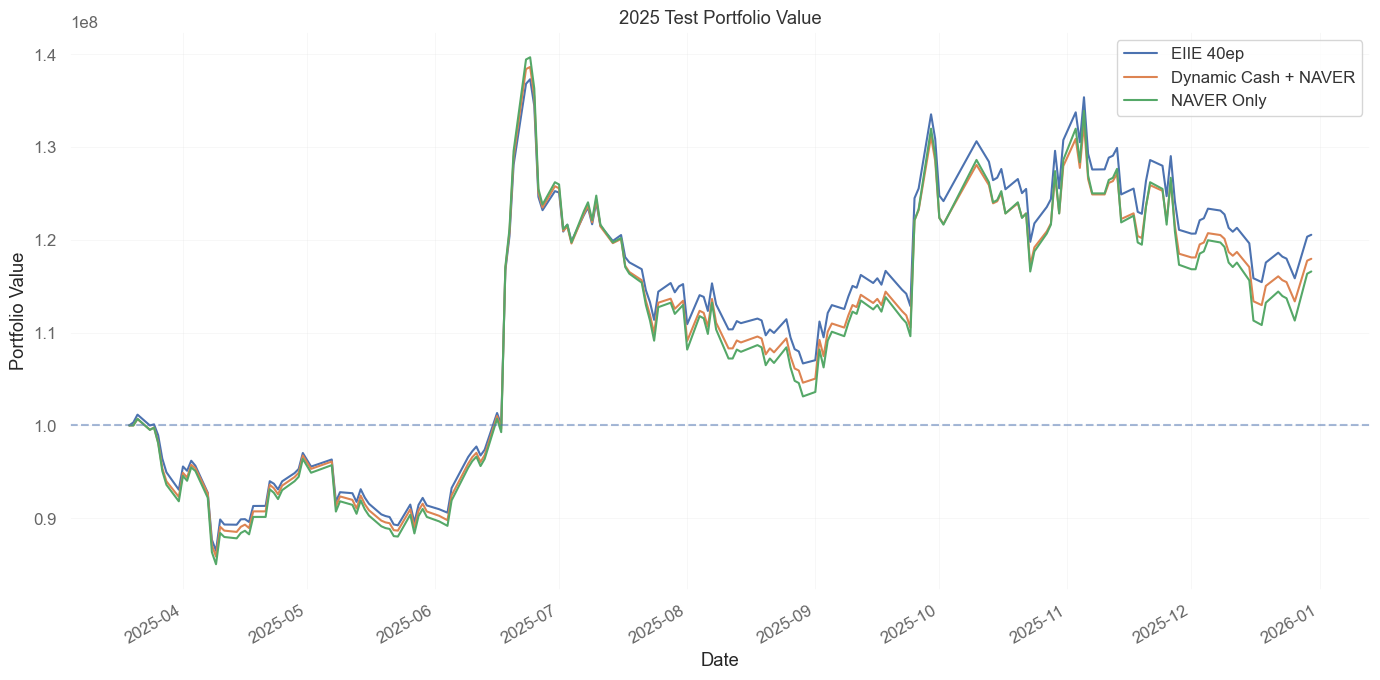

In [104]:
ax = test_curves.plot(
    figsize=(14, 7)
)

plt.axhline(
    INITIAL_AMOUNT,
    linestyle="--",
    alpha=0.5
)

plt.title("2025 Test Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "test_2025_portfolio_value.png",
    dpi=200
)

plt.show()

In [105]:
test_curves.to_csv(
    RESULTS_DIR / "test_2025_portfolio_value.csv",
    encoding="utf-8-sig"
)

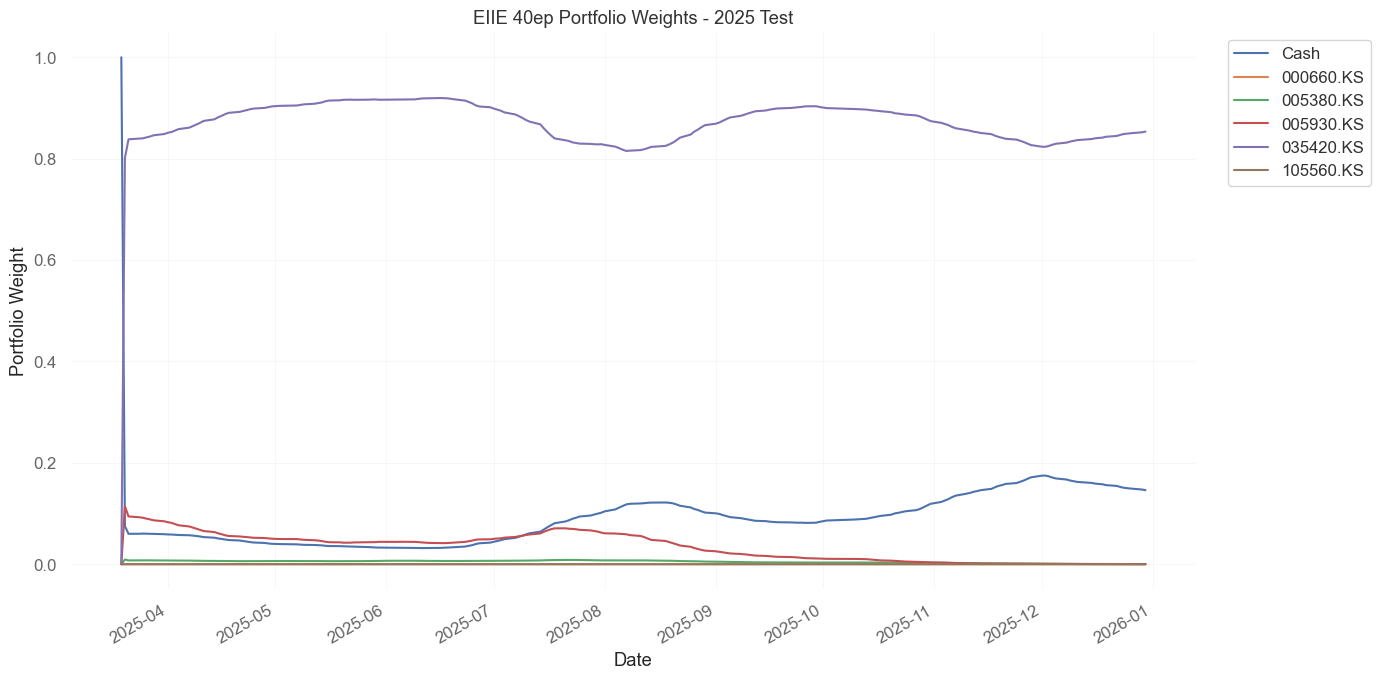

In [106]:
actions_test_40ep.plot(
    figsize=(14, 7)
)

plt.title("EIIE 40ep Portfolio Weights - 2025 Test")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "test_2025_eiie_weights.png",
    dpi=200
)

plt.show()

In [107]:
episode_results = pd.DataFrame({
    "Episodes": [
        5,
        10,
        20,
        40
    ],
    "Validation Return (%)": [
        -0.473680,
        -0.156510,
        1.321220,
        6.315410
    ]
})

episode_results

,Episodes,Validation Return (%)
0,5,-0.47368
1,10,-0.15651
2,20,1.32122
3,40,6.31541


In [108]:
episode_results.to_csv(
    RESULTS_DIR / "validation_episode_results.csv",
    index=False,
    encoding="utf-8-sig"
)

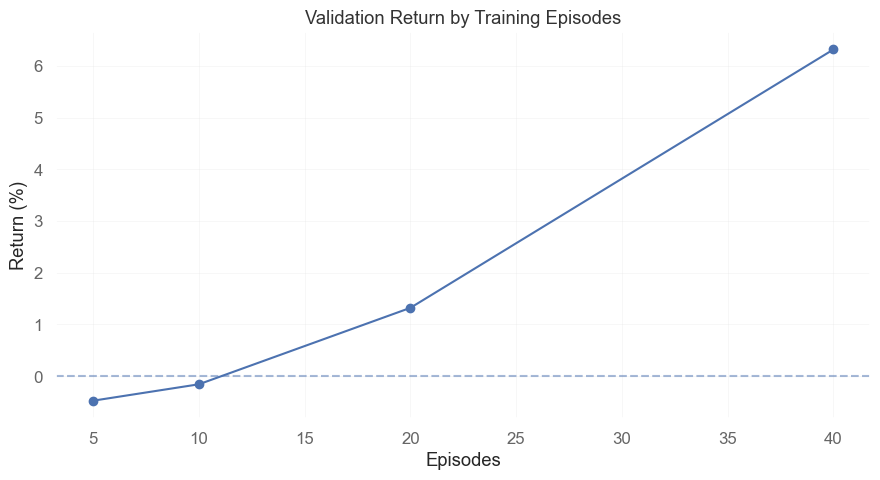

In [109]:
plt.figure(figsize=(9, 5))

plt.plot(
    episode_results["Episodes"],
    episode_results["Validation Return (%)"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.title("Validation Return by Training Episodes")
plt.xlabel("Episodes")
plt.ylabel("Return (%)")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "validation_episode_results.png",
    dpi=200
)

plt.show()